1. Importar as bibliotecas

In [27]:
# Importação das bibliotecas que utilizaremos
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy
from scipy.stats import variation
import seaborn as sns

2. Definir a variável "file" pelo nome da planilha.

In [28]:
# Importação do arquivo de tabela a ser utilizado, através do path na seção "Files" do Colab, contendo as informações de resíduos sólidos
file='./Solid_waste_pt.xlsx'

3. Ler a planilha no Python.

In [29]:
# Visão geral da tabela
df=pd.read_excel(file)
df

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg
0,Zona Sul,Reciclável,Comercial,Aterro Sanitário,1057.3,80.8,2.0,14.7,138.7,79.7,15.1
1,Zona Oeste,Reciclável,Comercial,Reciclagem,533.3,82.4,2.0,9.1,119.1,85.4,17.9
2,Centro,Reciclável,Comercial,Reciclagem,529.7,72.7,2.0,24.0,223.2,81.6,13.9
3,Zona Oeste,Reciclável,Comercial,Reciclagem,486.3,67.4,2.0,3.6,117.9,82.0,18.8
4,Zona Leste,Reciclável,Comercial,Aterro Sanitário,527.1,40.0,2.0,16.7,164.2,88.0,14.7
...,...,...,...,...,...,...,...,...,...,...,...
285,Zona Leste,Orgânico,Residencial,Aterro Sanitário,275.9,371.8,77.0,17.2,178.8,5.2,6.5
286,Zona Norte,Orgânico,Comercial,Aterro Sanitário,471.8,338.4,77.2,52.9,262.3,5.0,8.1
287,Zona Leste,Orgânico,Residencial,Aterro Sanitário,356.3,341.2,77.6,18.0,184.2,10.1,3.6
288,Zona Oeste,Orgânico,Comercial,Reciclagem,674.9,316.9,78.5,5.1,94.1,8.1,8.8


In [30]:
# Distribuicao de frequencia absoluta em classes de mesma amplitude
# (intervalos fechados a esquerda e abertos a direita: [a, b))
classes = range(0,40,10)
coluna = 'Poder_Calorifico_MJkg'
frequencia_Poder_Calorifico_MJkg = pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts().sort_index()
frequencia_Poder_Calorifico_MJkg

,count
Poder_Calorifico_MJkg,
"[0, 10)",124
"[10, 20)",132
"[20, 30)",34


In [31]:
# Frequencia relativa percentual de cada classe
frequencia_relativa_Poder_Calorifico_MJkg = round(pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts(normalize=True).sort_index() * 100, 2)
frequencia_relativa_Poder_Calorifico_MJkg

,proportion
Poder_Calorifico_MJkg,
"[0, 10)",42.76
"[10, 20)",45.52
"[20, 30)",11.72


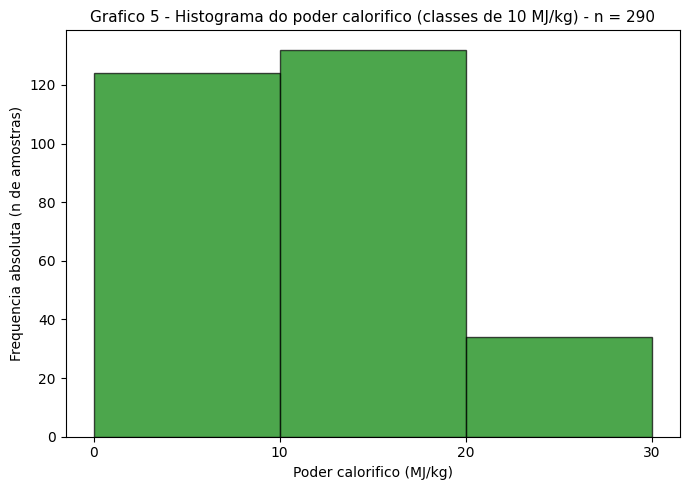

In [32]:
# Histograma 1: usa exatamente as classes da tabela de distribuicao de frequencias
classes = range(0,40,10)
plt.figure(figsize=(7, 5))
plt.hist(df.Poder_Calorifico_MJkg, bins=classes, rwidth=1, color='green', alpha=0.7, edgecolor='black')
plt.xticks(ticks=[0, 10, 20, 30])
plt.xlabel("Poder calorifico (MJ/kg)", size=10)
plt.ylabel("Frequencia absoluta (n de amostras)", size=10)
plt.title("Grafico 5 - Histograma do poder calorifico (classes de 10 MJ/kg) - n = 290", size=11)
plt.tight_layout()
plt.show()

4. **Histograma**

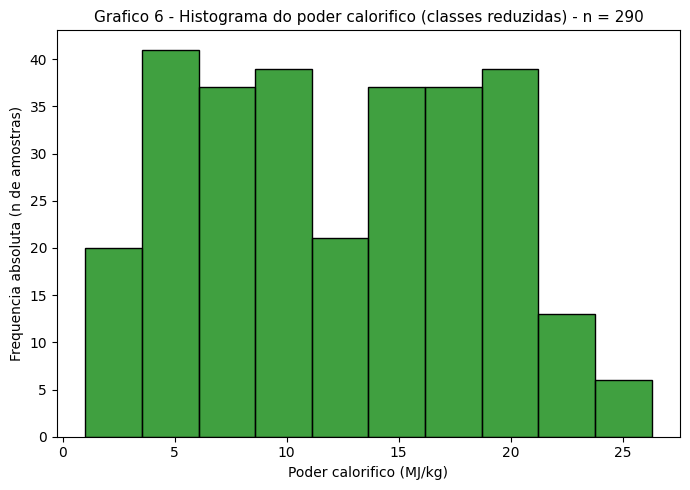

In [33]:
# Histograma 2: classes de menor amplitude, com finalidade exploratoria
# (intervalos mais estreitos revelam detalhes da forma da distribuicao)
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="Poder_Calorifico_MJkg", kde=False, color='green', edgecolor='black')
plt.xlabel("Poder calorifico (MJ/kg)", size=10)
plt.ylabel("Frequencia absoluta (n de amostras)", size=10)
plt.title("Grafico 6 - Histograma do poder calorifico (classes reduzidas) - n = 290", size=11)
plt.tight_layout()
plt.show()

5. VALORES MÍNIMO E MÁXIMO DO CONJUNTO DE DADOS.

In [34]:
valormin=min(df.Poder_Calorifico_MJkg)
valormax=max(df.Poder_Calorifico_MJkg)
valormin,valormax

(1.0, 26.3)

6. **Medidas de Tendência Central**


*   Média, Moda e Mediana


In [35]:
#cálculo da Média, indicando Dataframe e a coluna em questão, no exemplo df.Poder_Calorifico_MJkg
df.Poder_Calorifico_MJkg.mean()

np.float64(12.241724137931033)

In [36]:
# com 2 casas decimais
df.Poder_Calorifico_MJkg.mean().round(2)

np.float64(12.24)

In [37]:
# cálculo da moda. Mesmas indicações
df.Poder_Calorifico_MJkg.mode()

,Poder_Calorifico_MJkg
0,8.8
1,19.2


In [38]:
#cálculo da mediana.
df.Poder_Calorifico_MJkg.median()

11.95

In [39]:
#comando describe mostra várias medidas das variáveis quantitativas, incluindo média e mediana.
df.Poder_Calorifico_MJkg.describe().round(2)

,Poder_Calorifico_MJkg
count,290.00
mean,12.24
std,6.21
min,1.00
25%,6.70
50%,11.95
75%,17.40
max,26.30


7. **Tabela de distribuição de frequências (com frequências acumuladas)**

In [40]:
# Tabela final: frequencias absoluta, relativa, absoluta acumulada e relativa acumulada
tabela_poder_calorifico = pd.DataFrame({
    'Frequência absoluta': frequencia_Poder_Calorifico_MJkg,
    'Frequência relativa (%)': frequencia_relativa_Poder_Calorifico_MJkg
})
tabela_poder_calorifico['Frequência absoluta acumulada'] = tabela_poder_calorifico['Frequência absoluta'].cumsum()
tabela_poder_calorifico['Frequência relativa acumulada (%)'] = round(
    tabela_poder_calorifico['Frequência absoluta acumulada'] / tabela_poder_calorifico['Frequência absoluta'].sum() * 100, 2)

tabela_poder_calorifico = tabela_poder_calorifico.reset_index()
tabela_poder_calorifico = tabela_poder_calorifico.rename(columns={'Poder_Calorifico_MJkg': 'Intervalos', 'index': 'Intervalos'})

display(tabela_poder_calorifico)

,Intervalos,Frequência absoluta,Frequência relativa (%),Frequência absoluta acumulada,Frequência relativa acumulada (%)
0,"[0, 10)",124,42.76,124,42.76
1,"[10, 20)",132,45.52,256,88.28
2,"[20, 30)",34,11.72,290,100.00


8. Tabela com as frequências dos intervalor de Poder Calorífico

In [41]:
tabela_poder_calorifico.to_excel("Tabela_Frequencia_Poder_Calorifico.xlsx", sheet_name="Dados", index=False)

9. **Amplitude total do conjunto de dados**

In [42]:
# Amplitude total = maior valor observado - menor valor observado
amplitude = df.Poder_Calorifico_MJkg.max() - df.Poder_Calorifico_MJkg.min()
print("Valor minimo ...:", df.Poder_Calorifico_MJkg.min(), "MJ/kg")
print("Valor maximo ...:", df.Poder_Calorifico_MJkg.max(), "MJ/kg")
print("Amplitude total :", round(amplitude, 2), "MJ/kg")

Valor minimo ...: 1.0 MJ/kg
Valor maximo ...: 26.3 MJ/kg
Amplitude total : 25.3 MJ/kg


Calculo dos quartis Q1, Q2 e Q3

In [43]:
#Calculo do primeiro quartil - Q1
Q1 = df.Poder_Calorifico_MJkg.quantile(0.25)
Q1

np.float64(6.7)

In [44]:
#Calculo do segundo quartil - Q2
Q2 = df.Poder_Calorifico_MJkg.quantile(0.50)
Q2

np.float64(11.95)

In [45]:
#Calculo do terceiro quartil - Q3
Q3 = df.Poder_Calorifico_MJkg.quantile(0.75)
Q3

np.float64(17.4)

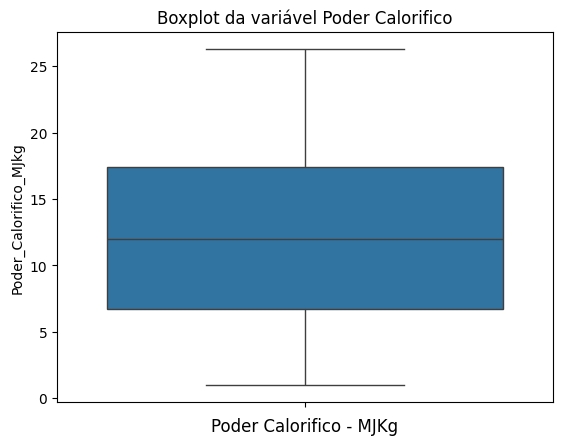

In [46]:
sns.boxplot(data=df.Poder_Calorifico_MJkg, orient="v")
plt.xlabel('Poder Calorifico - MJKg',fontsize=12)
plt.title('Boxplot da variável Poder Calorifico',fontsize=12)
plt.show()

In [47]:
linf = Q1 - 1.5 * (Q3 - Q1)
lsup = Q3 + 1.5 * (Q3 - Q1)
print(f"linf: {linf.round(2)} MJ/kg")
print(f"lsup: {lsup.round(2)} MJ/kg")

linf: -9.35 MJ/kg
lsup: 33.45 MJ/kg


In [48]:
df[df.Poder_Calorifico_MJkg < linf]

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg


In [49]:
df[df.Poder_Calorifico_MJkg > lsup]

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg


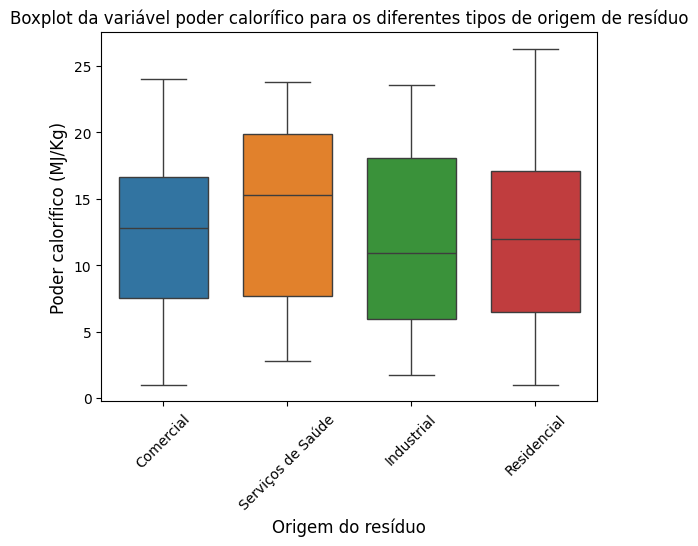

In [50]:
sns.boxplot(data=df,x="Origem_Residuo", y = "Poder_Calorifico_MJkg", hue="Origem_Residuo", fill=True,gap=.1)
plt.xlabel('Origem do resíduo',fontsize=12)
plt.ylabel('Poder calorífico (MJ/Kg)',fontsize=12)
plt.title('Boxplot da variável poder calorífico para os diferentes tipos de origem de resíduo',fontsize=12)
plt.xticks(rotation = 45)
plt.show()

In [51]:
#calcular o desvio padrão amostral do poder calorifíco
df.Poder_Calorifico_MJkg.std()

6.20973260486978

In [56]:
#coeficiente de variação (amostral)
variacao = scipy.stats.variation(df.Poder_Calorifico_MJkg,ddof=1)*100
print(variacao.round(2),"%")

50.73 %
